[[ 2.55499320e-01 -1.47115220e+00]
 [-2.85321181e-01 -9.65244186e-01]
 [ 5.18450297e-01  2.03710036e-01]
 [ 5.53627885e-01 -1.46878514e+00]
 [ 8.60575224e-01 -1.30647524e+00]
 [-1.73882839e+00 -1.01746810e-01]
 [ 7.86015018e-01 -1.43798376e+00]
 [ 1.98238385e-01 -1.30157114e+00]
 [ 6.49309818e-03  1.21994387e+00]
 [-1.37885193e+00  1.09608124e+00]
 [ 1.67091844e+00  6.44825019e-02]
 [ 5.00407160e-01  1.34188342e-01]
 [-3.06501465e-01 -9.36737557e-01]
 [ 1.09550215e+00 -1.46481572e+00]
 [ 4.98061913e-01  2.44541746e-01]
 [-6.21691916e-01  1.50982233e+00]
 [ 1.48622095e+00 -4.80873692e-01]
 [-1.01521489e+00  1.42591101e+00]
 [ 6.90997916e-01 -1.59029570e+00]
 [-4.90022499e-01 -8.76714839e-02]
 [-1.38918679e-01 -8.96785673e-01]
 [-1.09780431e+00  1.28892630e+00]
 [-1.58884845e+00  4.91066133e-01]
 [-1.55964295e+00  3.93459586e-01]
 [ 5.60064665e-01 -1.64118948e+00]
 [-1.45733424e+00  7.16173481e-01]
 [-9.19631158e-02 -1.09485068e+00]
 [ 1.74743230e+00  1.30905235e-03]
 [ 8.58924074e-01 -1

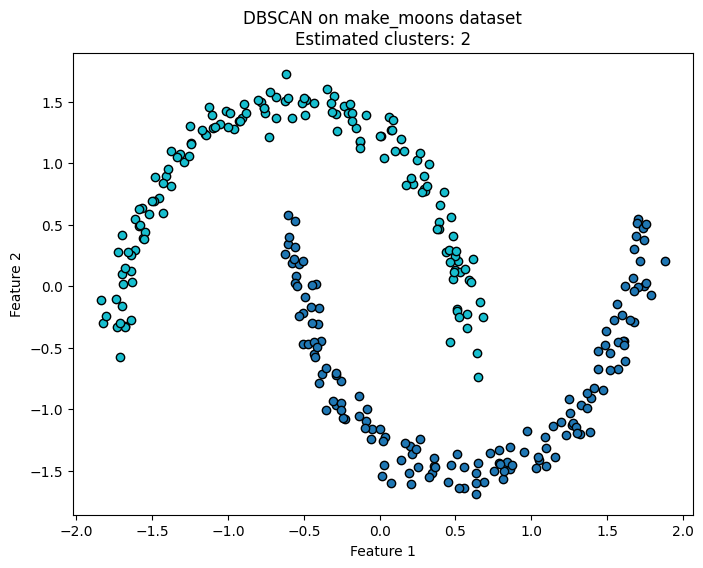

In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Step 1: Generate non-linear data (two interleaving half circles)
X, y = make_moons(n_samples=300, noise=0.05, random_state=0)

# Step 2: Scale the data
X = StandardScaler().fit_transform(X)
print(X)
# Step 3: Apply DBSCAN
db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X)

print(labels)
print(len(set(labels)))
# print(1 if -1 in labels else 0)
# Step 4: Count clusters and noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# Step 5: Visualize the clusters
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = [plt.cm.tab10(each)
          for each in np.linspace(0, 1, len(unique_labels))]


print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black for noise
        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title(f"DBSCAN on make_moons dataset\nEstimated clusters: {n_clusters}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Sample Data:
    CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                  15                      39
1           2                  16                      81
2           3                  17                       6
3           4                  18                      77
4           5                  19                      40

Number of clusters found: 3
Number of noise points: 7


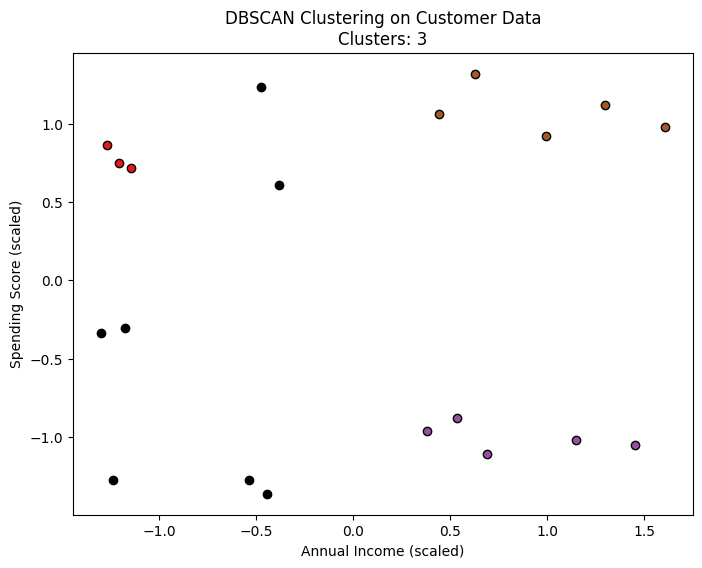

array([-1,  0, -1,  0, -1,  0, -1, -1, -1, -1,  1,  2,  1,  2,  1,  2,  1,
        2,  1,  2])

In [25]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Step 2: Create sample customer data (similar to Mall Customers dataset)
data = pd.DataFrame({
    'CustomerID': range(1, 21),
    'Annual Income (k$)': [15, 16, 17, 18, 19, 20, 40, 42, 43, 45,
                           70, 72, 75, 78, 80, 90, 95, 100, 105, 110],
    'Spending Score (1-100)': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72,
                               17, 88, 20, 97, 12, 83, 15, 90, 14, 85]
})

print("Sample Data:\n", data.head())

# Step 3: Select useful columns for clustering
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 4: Standardize the data (DBSCAN is distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply DBSCAN
# eps = neighborhood radius; min_samples = minimum points to form a cluster
dbscan = DBSCAN(eps=0.6, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

# Step 6: Add cluster labels to the dataset
data['Cluster'] = labels

# Step 7: Check number of clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\nNumber of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Step 8: Visualize clusters
plt.figure(figsize=(8,6))
unique_labels = set(labels)
colors = [plt.cm.Set1(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # black for noise
    class_member_mask = (labels == k)
    xy = X_scaled[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title(f"DBSCAN Clustering on Customer Data\nClusters: {n_clusters}")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()
labels
